In [6]:
import subprocess, os

# Kiểm tra GPU
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout)

# Cài ultralytics phiên bản mới nhất (có YOLO26)
subprocess.run(['pip', 'install', '-q', 'ultralytics>=8.4.0'], check=True)
subprocess.run(['pip', 'install', '-q', 'opencv-python-headless',
                'matplotlib', 'seaborn', 'pandas', 'Pillow', 'tqdm'], check=True)

print("\n✅ Cài đặt hoàn tất!")


Thu Jul 16 06:44:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             13W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Cell 2

In [7]:
import os, json, glob, shutil, random
import xml.etree.ElementTree as ET
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import torch
from ultralytics import YOLO

print("✅ Import xong!")


✅ Import xong!


Cell 3

In [8]:
# %%
# ============================================================
# CELL 3: ĐƯỜNG DẪN DATASET
# ============================================================

# BCCD Detection dataset (Supervisely JSON format)
BCCD_ROOT   = Path("/kaggle/input/datasets/orvile/bccd-blood-cell-count-and-detection-dataset")
WORKING_DIR = Path("/kaggle/working")

# Dataset đã chia sẵn train/val/test
SPLITS = {
    'train': BCCD_ROOT / 'train',
    'val':   BCCD_ROOT / 'val',
    'test':  BCCD_ROOT / 'test',
}

print("✅ Kiểm tra dataset:")
for split, path in SPLITS.items():
    img_count = len(list((path / 'img').glob('*'))) if (path / 'img').exists() else 0
    ann_count = len(list((path / 'ann').glob('*.json'))) if (path / 'ann').exists() else 0
    print(f"  {split:5s}: {img_count:3d} ảnh | {ann_count:3d} annotations")

# Classes
CLASS_NAMES = ['RBC', 'WBC', 'Platelets']
CLASS_MAP   = {'RBC': 0, 'WBC': 1, 'Platelets': 2}
print(f"\n📌 Classes: {CLASS_NAMES}")


✅ Kiểm tra dataset:
  train: 205 ảnh | 205 annotations
  val  :  87 ảnh |  87 annotations
  test :  72 ảnh |  72 annotations

📌 Classes: ['RBC', 'WBC', 'Platelets']


Đọc test: 100%|██████████| 72/72 [00:00<00:00, 345.30it/s]



📊 Tổng bounding boxes: 4888

🔢 Phân bố class:
class
RBC          4155
WBC           372
Platelets     361
Name: count, dtype: int64

📂 Phân bố theo split:
class  Platelets   RBC  WBC
split                      
test          69   805   71
train        209  2382  214
val           83   968   87


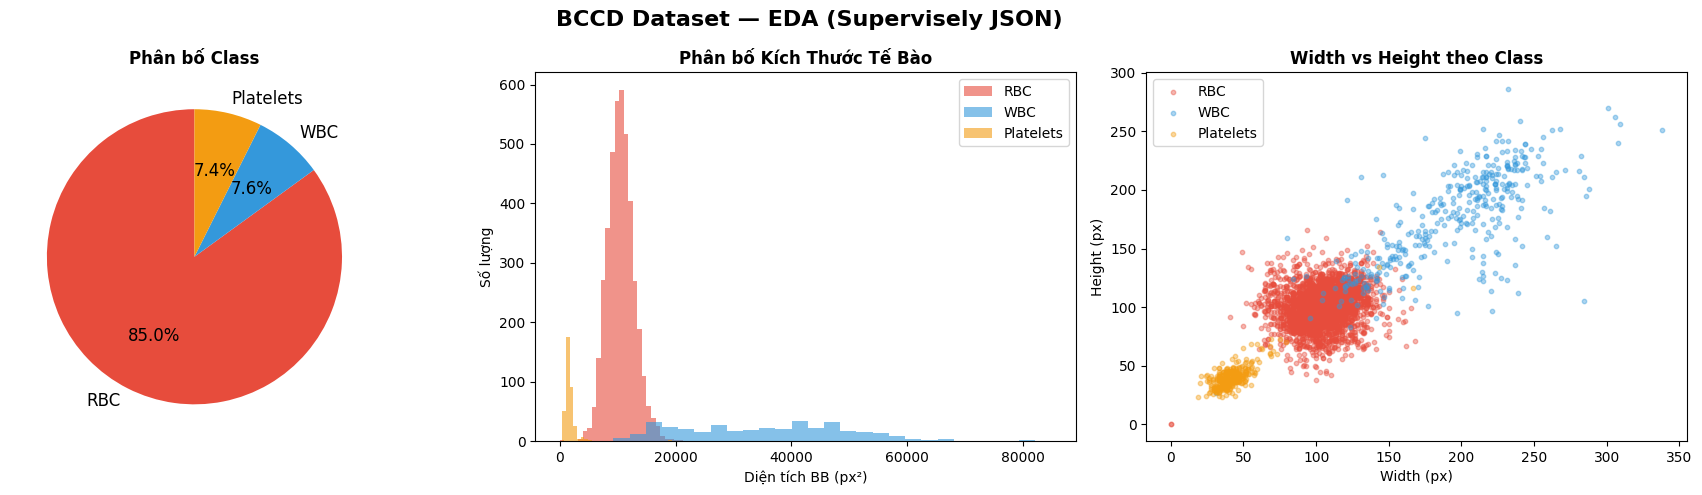

✅ EDA hoàn tất!


In [9]:
# %%
# ============================================================
# CELL 4: EDA — PHÂN TÍCH DỮ LIỆU
# ============================================================

def read_supervisely_json(json_path):
    """Đọc annotation từ Supervisely JSON, trả về list dict."""
    with open(json_path) as f:
        data = json.load(f)
    img_h = data['size']['height']
    img_w = data['size']['width']
    records = []
    for obj in data.get('objects', []):
        cls = obj.get('classTitle', '').strip()
        if cls not in CLASS_MAP:
            continue
        ext = obj['points']['exterior']
        x1, y1 = ext[0]
        x2, y2 = ext[1]
        w = abs(x2 - x1)
        h = abs(y2 - y1)
        records.append({
            'class': cls,
            'width': w, 'height': h,
            'area': w * h,
            'img_w': img_w, 'img_h': img_h,
        })
    return records

# Thu thập thống kê toàn bộ splits
all_records = []
for split, path in SPLITS.items():
    ann_dir = path / 'ann'
    if not ann_dir.exists():
        continue
    for json_path in tqdm(sorted(ann_dir.glob('*.json')), desc=f"Đọc {split}"):
        recs = read_supervisely_json(json_path)
        for r in recs:
            r['split'] = split
        all_records.extend(recs)

df = pd.DataFrame(all_records)
print(f"\n📊 Tổng bounding boxes: {len(df)}")
print(f"\n🔢 Phân bố class:")
print(df['class'].value_counts())
print(f"\n📂 Phân bố theo split:")
print(df.groupby(['split','class']).size().unstack(fill_value=0))

# Visualize EDA
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('BCCD Dataset — EDA (Supervisely JSON)', fontsize=16, fontweight='bold')
colors = ['#e74c3c', '#3498db', '#f39c12']

counts = df['class'].value_counts().reindex(CLASS_NAMES, fill_value=0)
axes[0].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Phân bố Class', fontweight='bold')

for cls, c in zip(CLASS_NAMES, colors):
    sub = df[df['class'] == cls]['area']
    if not sub.empty:
        axes[1].hist(sub, bins=30, alpha=0.6, color=c, label=cls)
axes[1].set_xlabel('Diện tích BB (px²)')
axes[1].set_ylabel('Số lượng')
axes[1].set_title('Phân bố Kích Thước Tế Bào', fontweight='bold')
axes[1].legend()

for cls, c in zip(CLASS_NAMES, colors):
    sub = df[df['class'] == cls]
    axes[2].scatter(sub['width'], sub['height'], alpha=0.4, color=c, label=cls, s=10)
axes[2].set_xlabel('Width (px)')
axes[2].set_ylabel('Height (px)')
axes[2].set_title('Width vs Height theo Class', fontweight='bold')
axes[2].legend()

plt.tight_layout()
plt.savefig(WORKING_DIR / 'eda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA hoàn tất!")

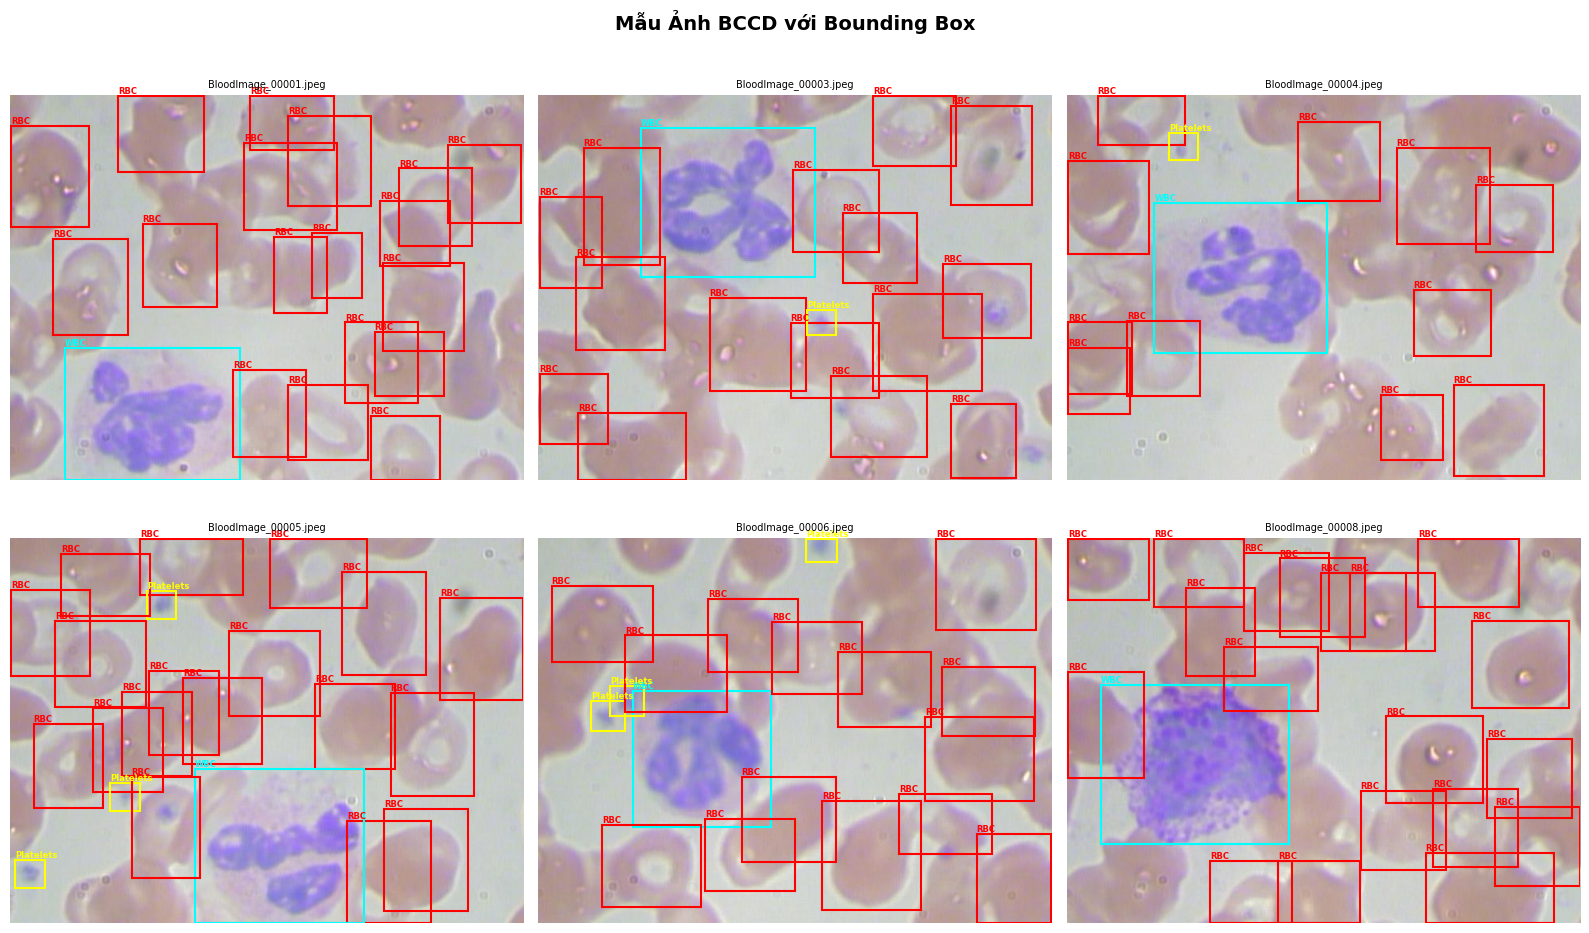

✅ Visualize mẫu ảnh xong!


In [10]:
# %%
# ============================================================
# CELL 5: VISUALIZE MẪU ẢNH VỚI BOUNDING BOX
# ============================================================

def draw_sample_json(json_path, img_dir, ax):
    """Vẽ bounding box từ Supervisely JSON lên ảnh."""
    with open(json_path) as f:
        data = json.load(f)
    # Tên ảnh = tên json bỏ đuôi .json
    img_name = json_path.name.replace('.json', '')
    img_path = img_dir / img_name
    if not img_path.exists():
        # thử tìm theo stem
        cands = list(img_dir.glob(f"{json_path.stem.replace('.jpeg','').replace('.jpg','')}*"))
        if not cands:
            ax.axis('off')
            return
        img_path = cands[0]

    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    ax.imshow(img)

    color_map = {'RBC': 'red', 'WBC': 'cyan', 'Platelets': 'yellow'}
    for obj in data.get('objects', []):
        cls = obj.get('classTitle', '').strip()
        if cls not in CLASS_MAP:
            continue
        ext = obj['points']['exterior']
        x1, y1 = ext[0]
        x2, y2 = ext[1]
        rect = patches.Rectangle((x1, y1), abs(x2-x1), abs(y2-y1),
                                   linewidth=1.5, edgecolor=color_map.get(cls, 'white'),
                                   facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1-3, cls, color=color_map.get(cls, 'white'),
                fontsize=6, fontweight='bold')
    ax.set_title(img_path.name, fontsize=7)
    ax.axis('off')

# Lấy 6 ảnh mẫu từ train
train_jsons = sorted((SPLITS['train'] / 'ann').glob('*.json'))[:6]
train_img   = SPLITS['train'] / 'img'

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Mẫu Ảnh BCCD với Bounding Box', fontsize=14, fontweight='bold')
for json_path, ax in zip(train_jsons, axes.flatten()):
    draw_sample_json(json_path, train_img, ax)
plt.tight_layout()
plt.savefig(WORKING_DIR / 'sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Visualize mẫu ảnh xong!")



In [11]:
# %%
# ============================================================
# CELL 6: CONVERT SUPERVISELY JSON → YOLO FORMAT
# ============================================================

YOLO_DIR = WORKING_DIR / "bccd_yolo"

def convert_split_to_yolo(split_name, split_path, yolo_dir):
    """Convert 1 split (train/val/test) từ Supervisely JSON sang YOLO."""
    img_dir = split_path / 'img'
    ann_dir = split_path / 'ann'
    out_img = yolo_dir / split_name / 'images'
    out_lbl = yolo_dir / split_name / 'labels'
    out_img.mkdir(parents=True, exist_ok=True)
    out_lbl.mkdir(parents=True, exist_ok=True)

    json_files = sorted(ann_dir.glob('*.json'))
    ok = 0
    for json_path in tqdm(json_files, desc=f"Convert {split_name}"):
        with open(json_path) as f:
            data = json.load(f)

        img_h = data['size']['height']
        img_w = data['size']['width']

        # Copy ảnh
        img_name = json_path.name.replace('.json', '')
        img_src  = img_dir / img_name
        if not img_src.exists():
            continue
        shutil.copy(img_src, out_img / img_src.name)

        # Tạo label YOLO
        lines = []
        for obj in data.get('objects', []):
            cls = obj.get('classTitle', '').strip()
            if cls not in CLASS_MAP:
                continue
            ext = obj['points']['exterior']
            x1, y1 = ext[0]
            x2, y2 = ext[1]
            # Normalize
            cx = max(0, min(1, (x1 + x2) / 2 / img_w))
            cy = max(0, min(1, (y1 + y2) / 2 / img_h))
            bw = max(0, min(1, abs(x2 - x1) / img_w))
            bh = max(0, min(1, abs(y2 - y1) / img_h))
            lines.append(f"{CLASS_MAP[cls]} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")

        if lines:
            lbl_name = img_src.stem + '.txt'
            (out_lbl / lbl_name).write_text("\n".join(lines))
            ok += 1

    print(f"  ✅ {split_name}: {ok}/{len(json_files)} ảnh converted")
    return ok

# Convert tất cả splits
for split_name, split_path in SPLITS.items():
    convert_split_to_yolo(split_name, split_path, YOLO_DIR)

print(f"\n📁 YOLO dataset: {YOLO_DIR}")

Convert train: 100%|██████████| 205/205 [00:01<00:00, 173.75it/s]


  ✅ train: 205/205 ảnh converted


Convert val: 100%|██████████| 87/87 [00:00<00:00, 185.98it/s]


  ✅ val: 87/87 ảnh converted


Convert test: 100%|██████████| 72/72 [00:00<00:00, 197.00it/s]

  ✅ test: 72/72 ảnh converted

📁 YOLO dataset: /kaggle/working/bccd_yolo


In [12]:
# %%
# ============================================================
# CELL 7: TẠO bccd.yaml
# ============================================================

yaml_content = f"""# BCCD Dataset — YOLO26
# Đề tài: Phát hiện & phân loại tế bào kết hợp XAI
# Nhóm: Nguyễn Quốc Vinh · Hồ Nhật Hào · Lê Trần Quốc Huy

path: {YOLO_DIR}
train: train/images
val:   val/images
test:  test/images

nc: 3
names:
  0: RBC
  1: WBC
  2: Platelets
"""

yaml_path = WORKING_DIR / "bccd.yaml"
yaml_path.write_text(yaml_content)
print("✅ bccd.yaml đã tạo:")
print(yaml_content)

✅ bccd.yaml đã tạo:
# BCCD Dataset — YOLO26
# Đề tài: Phát hiện & phân loại tế bào kết hợp XAI
# Nhóm: Nguyễn Quốc Vinh · Hồ Nhật Hào · Lê Trần Quốc Huy

path: /kaggle/working/bccd_yolo
train: train/images
val:   val/images
test:  test/images

nc: 3
names:
  0: RBC
  1: WBC
  2: Platelets



In [13]:
# %%
# ============================================================
# CELL 8: TRAIN YOLO26 — 2x T4 GPU (DDP)
# ============================================================

model = YOLO("yolo26n.pt")

results = model.train(
    data         = str(yaml_path),
    epochs       = 100,
    imgsz        = 640,
    batch        = 32,       # 16/GPU × 2 GPU
    device       = "0,1",   # 2x T4 GPU — DDP
    workers      = 4,
    patience     = 20,       # EarlyStopping
    optimizer    = "MuSGD",  # Optimizer mới của YOLO26
    lr0          = 0.01,
    lrf          = 0.01,
    momentum     = 0.937,
    weight_decay = 0.0005,
    warmup_epochs = 3,
    cos_lr       = True,
    mosaic       = 1.0,
    flipud       = 0.5,
    fliplr       = 0.5,
    hsv_h        = 0.015,
    hsv_s        = 0.7,
    hsv_v        = 0.4,
    degrees      = 10.0,
    translate    = 0.1,
    scale        = 0.5,
    project      = str(WORKING_DIR / "runs"),
    name         = "yolo26_bccd",
    exist_ok     = True,
    save         = True,
    save_period  = 10,
    plots        = True,
    verbose      = True,
)
print("✅ Training hoàn tất!")


Ultralytics 8.4.96 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
                                                       CUDA:1 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/bccd.yaml, degrees=10.0, deterministic=True, device=0,1, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yol

In [14]:

# %%
# ============================================================
# CELL 9: ĐÁNH GIÁ — mAP, Precision, Recall
# ============================================================

best_weights = WORKING_DIR / "runs" / "yolo26_bccd" / "weights" / "best.pt"
model_eval   = YOLO(str(best_weights))

metrics = model_eval.val(
    data    = str(yaml_path),
    imgsz   = 640,
    device  = "0",
    plots   = True,
    verbose = True,
)

print("\n" + "="*60)
print("📊 KẾT QUẢ YOLO26 — BCCD DATASET")
print("="*60)
print(f"  mAP@50       : {metrics.box.map50:.4f}")
print(f"  mAP@50-95    : {metrics.box.map:.4f}")
print(f"  Precision    : {metrics.box.mp:.4f}")
print(f"  Recall       : {metrics.box.mr:.4f}")
print("-"*60)
for i, cls_name in enumerate(CLASS_NAMES):
    if i < len(metrics.box.ap50):
        print(f"  {cls_name:12s} AP@50: {metrics.box.ap50[i]:.4f}")
print("="*60)



Ultralytics 8.4.96 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
YOLO26n summary (fused): 122 layers, 2,375,421 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 701.4±202.5 MB/s, size: 20.3 KB)
val: Scanning /kaggle/working/bccd_yolo/val/labels.cache... 87 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 87/87 21.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.2it/s 2.7s0.3s
                   all         87       1138      0.848      0.857      0.897      0.626
                   RBC         83        968      0.781      0.824       0.88      0.622
                   WBC         86         87      0.979      0.989      0.987      0.824
             Platelets         45         83      0.785      0.759      0.825      0.431
Speed: 1.1ms preprocess, 16.8ms inference, 0.0ms loss, 2.1ms postprocess per image
Results saved to /kaggle/working/runs/detect/va

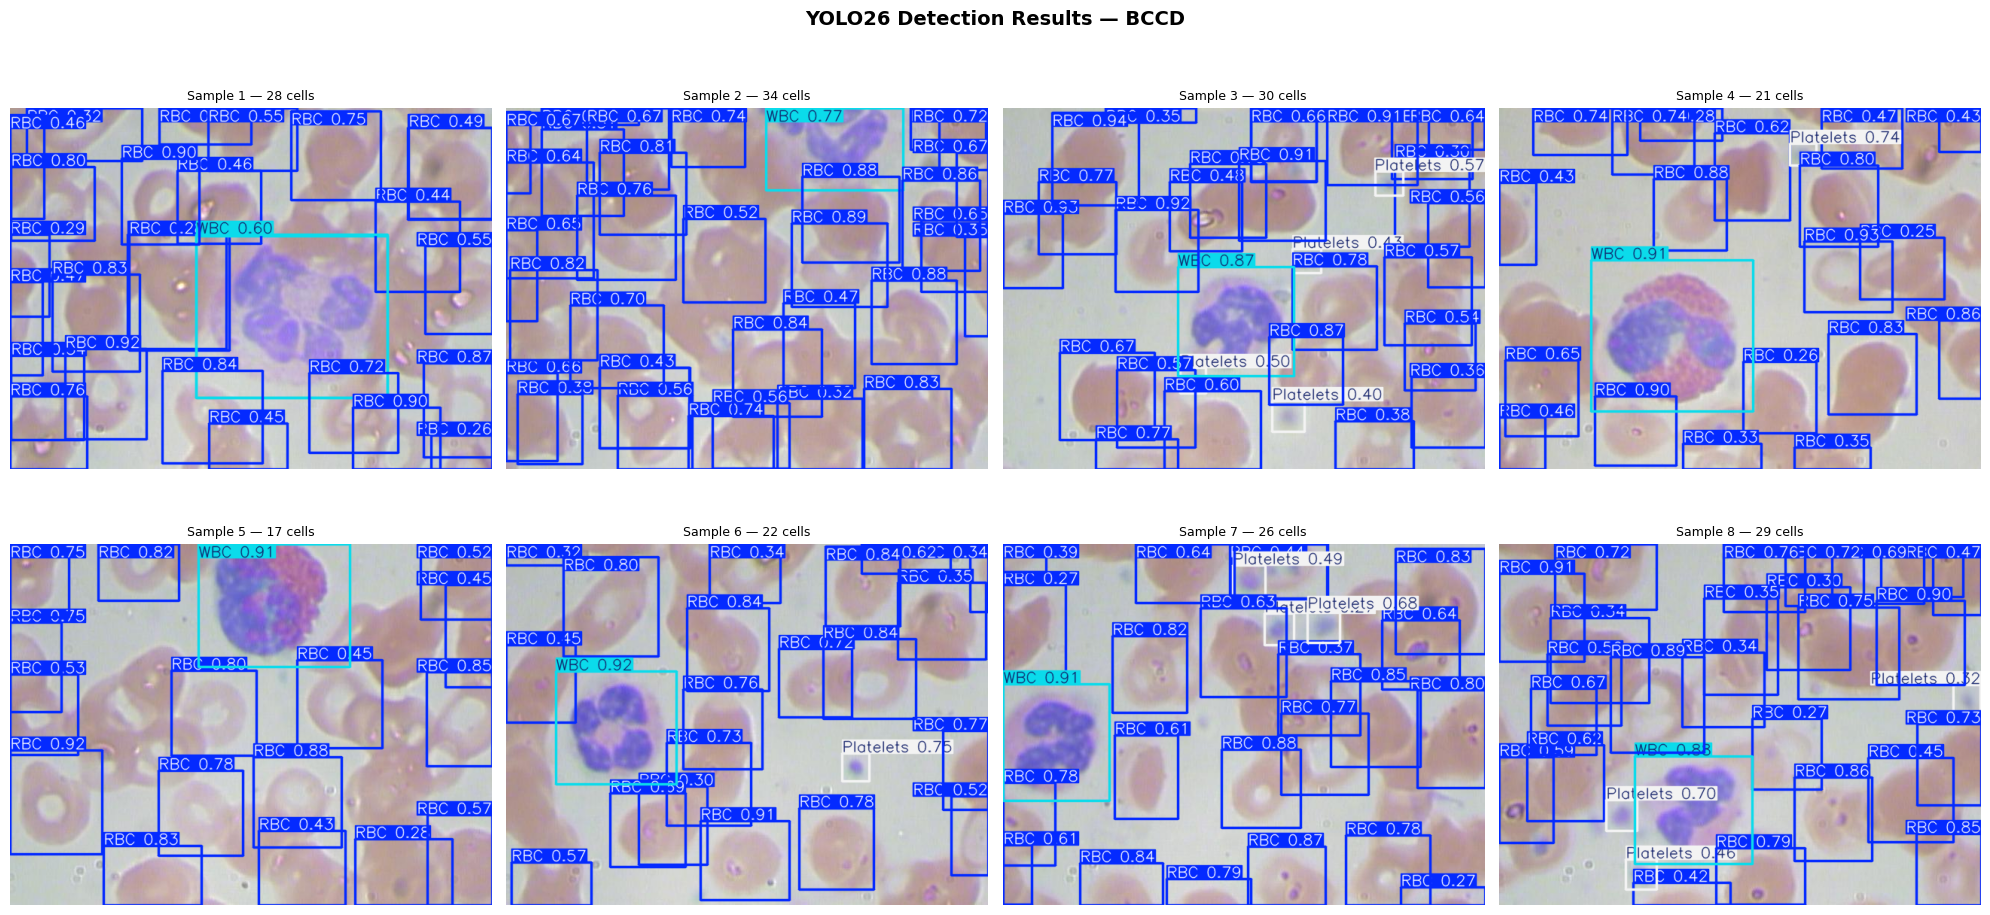

✅ Detection results saved!


In [15]:
# %%
# ============================================================
# CELL 10: VISUALIZE DETECTION RESULTS
# ============================================================

val_images = sorted((YOLO_DIR / 'val' / 'images').glob("*"))[:8]
fig, axes  = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('YOLO26 Detection Results — BCCD', fontsize=14, fontweight='bold')

for i, (img_path, ax) in enumerate(zip(val_images, axes.flatten())):
    res     = model_eval.predict(str(img_path), conf=0.25, verbose=False)[0]
    img_rgb = cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    n_det   = len(res.boxes)
    ax.set_title(f"Sample {i+1} — {n_det} cells", fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig(WORKING_DIR / 'detection_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Detection results saved!")

In [16]:
# %%
# ============================================================
# CELL 11: CROP CELL PATCHES → INPUT CHO QWEN3.5
# ============================================================

CROP_DIR = WORKING_DIR / "cell_patches_yolo"
for cls in CLASS_NAMES:
    (CROP_DIR / cls).mkdir(parents=True, exist_ok=True)

CONF_THR = 0.4
PADDING  = 5
crop_cnt = {c: 0 for c in CLASS_NAMES}

all_val_imgs = sorted((YOLO_DIR / 'val' / 'images').glob("*"))
for img_path in tqdm(all_val_imgs, desc="Cropping cells"):
    results = model_eval.predict(str(img_path), conf=CONF_THR, verbose=False)
    if not results:
        continue
    res  = results[0]
    img  = cv2.imread(str(img_path))
    h, w = img.shape[:2]
    for j, box in enumerate(res.boxes):
        cls_id   = int(box.cls[0])
        if cls_id >= len(CLASS_NAMES):
            continue
        cls_name = CLASS_NAMES[cls_id]
        conf     = float(box.conf[0])
        x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
        x1, y1 = max(0, x1-PADDING), max(0, y1-PADDING)
        x2, y2 = min(w, x2+PADDING), min(h, y2+PADDING)
        crop    = img[y1:y2, x1:x2]
        if crop.size == 0:
            continue
        out = cv2.resize(crop, (224, 224))
        fname = f"{img_path.stem}_b{j}_{conf:.2f}.jpg"
        cv2.imwrite(str(CROP_DIR / cls_name / fname), out)
        crop_cnt[cls_name] += 1

total = sum(crop_cnt.values())
print("✅ Cell patches hoàn tất!")
for cls, cnt in crop_cnt.items():
    print(f"  {cls:12s}: {cnt:5d} ảnh")
print(f"  {'TOTAL':12s}: {total:5d} ảnh")

Cropping cells: 100%|██████████| 87/87 [00:02<00:00, 40.73it/s]

✅ Cell patches hoàn tất!
  RBC         :  1334 ảnh
  WBC         :    89 ảnh
  Platelets   :    81 ảnh
  TOTAL       :  1504 ảnh


In [17]:
# %%
# ============================================================
# CELL 12: TỔNG KẾT
# ============================================================

print("=" * 65)
print("🎯 HOÀN THÀNH — YOLO26 BCCD DETECTION")
print("=" * 65)
print(f"  Model    : YOLO26n (NMS-Free · DFL-Free · MuSGD)")
print(f"  Dataset  : BCCD — Supervisely JSON")
print(f"  mAP@50   : {metrics.box.map50:.4f}")
print(f"  mAP@50-95: {metrics.box.map:.4f}")
print(f"  Precision: {metrics.box.mp:.4f}")
print(f"  Recall   : {metrics.box.mr:.4f}")
print(f"  Patches  : {total} ảnh (224×224) → sẵn sàng cho Qwen3.5")
print(f"  Best wts : {best_weights}")
print("=" * 65)
print("⏭️  BƯỚC TIẾP: Notebook 02 — Qwen3.5 Fine-tune + XAI")


🎯 HOÀN THÀNH — YOLO26 BCCD DETECTION
  Model    : YOLO26n (NMS-Free · DFL-Free · MuSGD)
  Dataset  : BCCD — Supervisely JSON
  mAP@50   : 0.8972
  mAP@50-95: 0.6255
  Precision: 0.8483
  Recall   : 0.8573
  Patches  : 1504 ảnh (224×224) → sẵn sàng cho Qwen3.5
  Best wts : /kaggle/working/runs/yolo26_bccd/weights/best.pt
⏭️  BƯỚC TIẾP: Notebook 02 — Qwen3.5 Fine-tune + XAI


Tải file

In [18]:
import zipfile
from pathlib import Path

WORKING_DIR = Path("/kaggle/working")
zip_path = WORKING_DIR / "notebook01_output.zip"

files_to_save = [
    # Model quan trọng nhất
    WORKING_DIR / "runs/yolo26_bccd/weights/best.pt",
    WORKING_DIR / "runs/yolo26_bccd/weights/last.pt",
    # Kết quả training
    WORKING_DIR / "runs/yolo26_bccd/results.png",
    WORKING_DIR / "runs/yolo26_bccd/confusion_matrix.png",
    # EDA + Evaluation plots
    WORKING_DIR / "eda_analysis.png",
    WORKING_DIR / "val_predictions.png",
]

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in files_to_save:
        if Path(f).exists():
            zf.write(f, Path(f).name)
            print(f"✅ {Path(f).name} ({Path(f).stat().st_size/1024/1024:.1f} MB)")
        else:
            print(f"⚠️  Không thấy: {Path(f).name}")

print(f"\n📦 notebook01_output.zip — Tải từ Output tab!")


✅ best.pt (5.1 MB)
✅ last.pt (5.1 MB)
✅ results.png (0.3 MB)
✅ confusion_matrix.png (0.1 MB)
✅ eda_analysis.png (0.2 MB)
⚠️  Không thấy: val_predictions.png

📦 notebook01_output.zip — Tải từ Output tab!
